# Time-Series Foundation Model

This notebook evaluates a pre-trained time-series foundation model for 24-hour appliance energy forecasting.

Chronos-Bolt Tiny is used as a lightweight zero-shot forecasting model. The model is applied directly to the historical appliance energy series without task-specific training.

The 24-hour forecast is evaluated using MAE, RMSE, MASE and forecast bias and compared later with the benchmark, SARIMAX and feature-based models.

In [1]:
%pip install -q chronos-forecasting

Note: you may need to restart the kernel to use updated packages.


C:\Users\LOJANA-UOH\anaconda3\python.exe: No module named pip


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from chronos import BaseChronosPipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FORECAST_DIR = PROJECT_ROOT / "outputs" / "forecasts"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

for directory in [
    FIGURE_DIR,
    FORECAST_DIR,
    METRICS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

DATA_FILE = (
    PROCESSED_DIR /
    "appliance_energy_hourly.csv"
)

print("Data file exists:", DATA_FILE.exists())

Data file exists: True


In [3]:
data = pd.read_csv(
    DATA_FILE,
    index_col="date",
    parse_dates=True
).sort_index()

TARGET = "Appliances"

target = data[TARGET].copy()

TEST_STEPS = 14 * 24
FORECAST_HORIZON = 24

train = target.iloc[:-TEST_STEPS].copy()
test = target.iloc[-TEST_STEPS:].copy()

first_24_test = test.iloc[:FORECAST_HORIZON]

print("Training observations:", len(train))
print("Forecast horizon:", len(first_24_test))

Training observations: 2954
Forecast horizon: 24


## Chronos-Bolt Tiny

Chronos-Bolt is a pre-trained time-series forecasting architecture that directly generates multi-step probabilistic forecasts from historical context.

The Tiny variant is used in this analysis to minimise computational cost while still providing a genuine foundation-model comparison.

The model is used in a zero-shot setting, meaning that no additional training or fine-tuning is performed on the appliance-energy dataset.

In [4]:
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-tiny",
    device_map="cpu",
    torch_dtype=torch.float32
)

print("Chronos-Bolt Tiny loaded successfully.")

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

C:\Users\LOJANA-UOH\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LOJANA-UOH\.cache\huggingface\hub\models--amazon--chronos-bolt-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Chronos-Bolt Tiny loaded successfully.


In [5]:
CONTEXT_LENGTH = 2048

context_values = (
    train
    .iloc[-CONTEXT_LENGTH:]
    .values
)

context_tensor = torch.tensor(
    context_values,
    dtype=torch.float32
)

print("Context length:", len(context_tensor))

Context length: 2048


In [6]:
with torch.no_grad():

    chronos_output = pipeline.predict(
        context_tensor,
        prediction_length=FORECAST_HORIZON
    )

print("Forecast tensor shape:")
print(chronos_output.shape)

Forecast tensor shape:
torch.Size([1, 9, 24])


In [7]:
chronos_median = (
    chronos_output[
        0,
        4,
        :
    ]
    .detach()
    .cpu()
    .numpy()
)

chronos_predictions = pd.Series(
    chronos_median,
    index=first_24_test.index,
    name="Chronos_Bolt_Tiny"
)

chronos_predictions.head()

date
2016-05-13 19:00:00    170.493042
2016-05-13 20:00:00    126.835060
2016-05-13 21:00:00     91.066055
2016-05-13 22:00:00     69.847794
2016-05-13 23:00:00     62.573780
Name: Chronos_Bolt_Tiny, dtype: float32

In [8]:
def calculate_rmse(
    y_true,
    y_pred
):
    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def calculate_mase(
    y_true,
    y_pred,
    y_train,
    seasonality=24
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    y_train = np.asarray(
        y_train,
        dtype=float
    )

    scale = np.mean(
        np.abs(
            y_train[seasonality:]
            -
            y_train[:-seasonality]
        )
    )

    if scale == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
        / scale
    )

In [9]:
chronos_metrics = pd.DataFrame([
    {
        "Model":
            "Chronos-Bolt-Tiny",

        "MAE":
            mean_absolute_error(
                first_24_test,
                chronos_predictions
            ),

        "RMSE":
            calculate_rmse(
                first_24_test,
                chronos_predictions
            ),

        "MASE":
            calculate_mase(
                first_24_test,
                chronos_predictions,
                train,
                seasonality=24
            ),

        "Bias":
            np.mean(
                chronos_predictions.values
                -
                first_24_test.values
            )
    }
])

chronos_metrics.round(3)

,Model,MAE,RMSE,MASE,Bias
0,Chronos-Bolt-Tiny,29.829,42.226,0.558,16.751


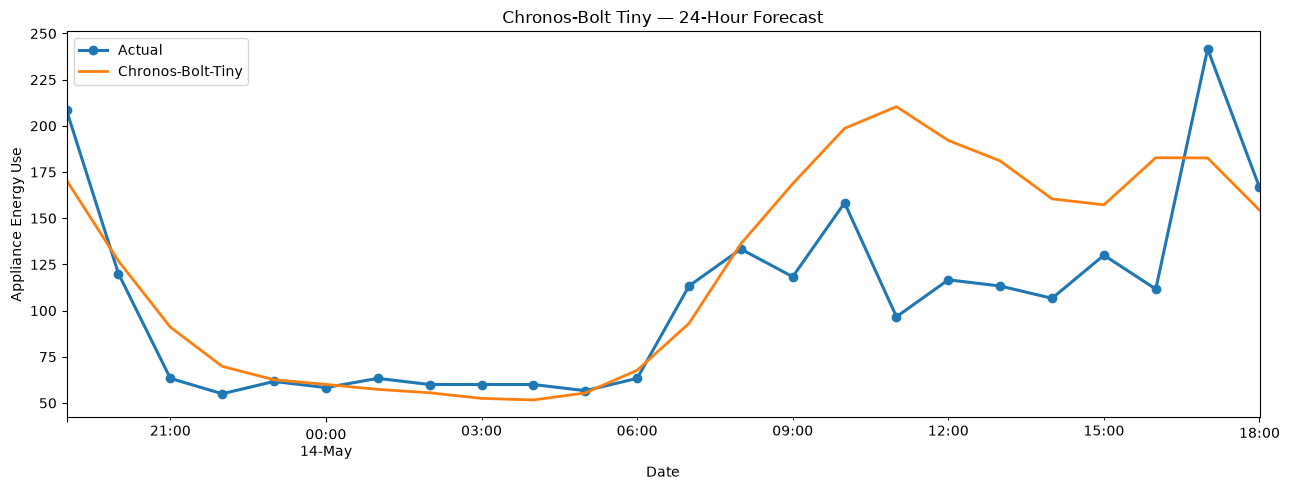

Figure saved.


In [10]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

first_24_test.plot(
    ax=ax,
    label="Actual",
    marker="o",
    linewidth=2.2
)

chronos_predictions.plot(
    ax=ax,
    label="Chronos-Bolt-Tiny",
    linewidth=2
)

ax.set_title(
    "Chronos-Bolt Tiny — 24-Hour Forecast"
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "Appliance Energy Use"
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "29_chronos_24h_forecast.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved.")

In [11]:
chronos_forecast_output = pd.DataFrame({
    "Actual":
        first_24_test,

    "Chronos_Bolt_Tiny":
        chronos_predictions
})

chronos_forecast_output.to_csv(
    FORECAST_DIR /
    "chronos_24h_forecast.csv"
)

chronos_metrics.to_csv(
    METRICS_DIR /
    "chronos_24h_metrics.csv",
    index=False
)

print(
    "Chronos forecasts and metrics saved successfully."
)

Chronos forecasts and metrics saved successfully.
